In [2]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../data/processed/reviews.db")  # open the database from Phase 3

def q(sql):
    return pd.read_sql(sql, conn)  # shortcut: run a SQL query and show the result as a table


In [3]:
# overview per app (Q1)
q("""
SELECT app_name,
       COUNT(*) AS reviews,
       ROUND(AVG(score), 2) AS avg_rating,
       ROUND(100.0 * SUM(CASE WHEN score = 1 THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_1_star,
       ROUND(100.0 * SUM(CASE WHEN score = 5 THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_5_star
FROM reviews
GROUP BY app_name
ORDER BY avg_rating DESC
""")

,app_name,reviews,avg_rating,pct_1_star,pct_5_star
0,Rocket Money,22596,4.04,18.3,69.6
1,YNAB,2064,3.63,22.2,53.5
2,Monarch Money,2443,3.56,23.1,48.9
3,Credit Karma,31383,3.32,32.4,48.3


In [4]:
#  rating trend over time, with a rolling average (Q1)
trend = q("""
WITH monthly AS (                         -- step 1: average rating per app per month
    SELECT app_name, month,
           COUNT(*) AS reviews,
           AVG(score) AS avg_rating
    FROM reviews
    GROUP BY app_name, month
)
SELECT app_name, month, reviews,
       ROUND(avg_rating, 2) AS avg_rating,
       ROUND(AVG(avg_rating) OVER (          -- step 2: 3-month rolling average
           PARTITION BY app_name
           ORDER BY month
           ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
       ), 2) AS rolling_3m
FROM monthly
ORDER BY app_name, month
""")
trend

,app_name,month,reviews,avg_rating,rolling_3m
0,Credit Karma,2023-06,1030,3.85,3.85
1,Credit Karma,2023-07,1058,3.80,3.83
2,Credit Karma,2023-08,1056,3.66,3.77
3,Credit Karma,2023-09,1021,3.73,3.73
4,Credit Karma,2023-10,1008,3.85,3.75
...,...,...,...,...,...
155,YNAB,2026-05,33,3.30,3.29
156,YNAB,2026-06,40,3.10,3.18
157,YNAB,2026-07,40,3.13,3.18
158,YNAB,2026-08,39,3.36,3.19


<Axes: title={'center': '3-month rolling average rating by app'}, xlabel='month', ylabel='Rating'>

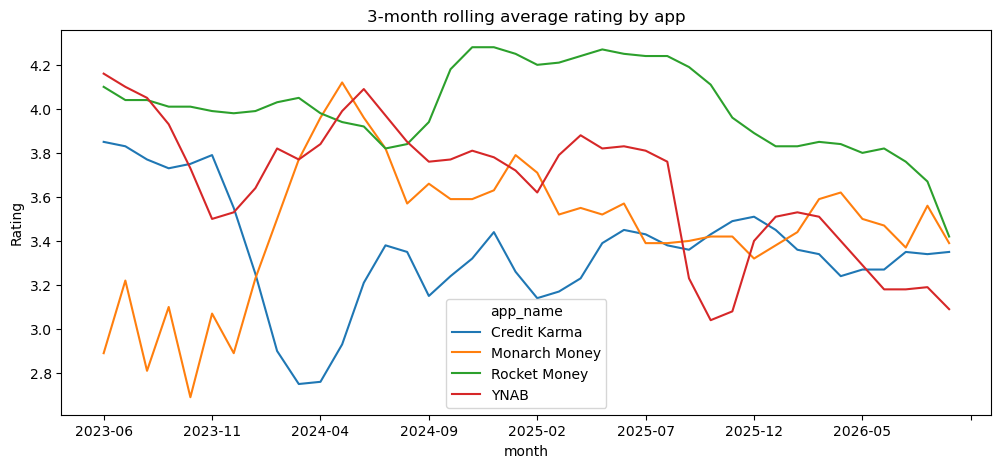

In [5]:
chart = trend.pivot(index="month", columns="app_name", values="rolling_3m")  # one column per app
chart.plot(figsize=(12, 5), title="3-month rolling average rating by app", ylabel="Rating")

In [10]:
# paid vs free apps (Q2)
q("""
SELECT CASE WHEN app_name IN ('YNAB', 'Monarch Money') THEN 'Paid'
            ELSE 'Free / freemium' END AS pricing_model,
       COUNT(*) AS reviews,
       ROUND(AVG(score), 2) AS avg_rating
FROM reviews
GROUP BY pricing_model
""")



,pricing_model,reviews,avg_rating
0,Free / freemium,53979,3.62
1,Paid,4507,3.59


In [7]:
# the mint shutdown periods 
q("""
SELECT app_name, mint_period,
       COUNT(*) AS reviews,
       ROUND(AVG(score), 2) AS avg_rating,
       ROUND(100.0 * SUM(mentions_mint) / COUNT(*), 1) AS pct_mention_mint
FROM reviews
GROUP BY app_name, mint_period
ORDER BY app_name, mint_period
""")

,app_name,mint_period,reviews,avg_rating,pct_mention_mint
0,Credit Karma,1_before_announcement,5212,3.78,0.0
1,Credit Karma,2_transition,6744,2.96,27.2
2,Credit Karma,3_after_shutdown,19427,3.32,4.9
3,Monarch Money,1_before_announcement,36,3.06,13.9
4,Monarch Money,2_transition,283,3.68,47.7
5,Monarch Money,3_after_shutdown,2124,3.55,14.2
6,Rocket Money,1_before_announcement,2263,4.02,0.5
7,Rocket Money,2_transition,2492,4.01,3.3
8,Rocket Money,3_after_shutdown,17841,4.05,0.8
9,YNAB,1_before_announcement,315,3.88,1.0


In [8]:
# were former Mint users satisfied? (Q7, a first look)
q("""
SELECT app_name,
       CASE WHEN mentions_mint = 1 THEN 'Mentions Mint' ELSE 'No mention' END AS group_name,
       COUNT(*) AS reviews,
       ROUND(AVG(score), 2) AS avg_rating
FROM reviews
GROUP BY app_name, group_name
ORDER BY app_name, group_name
""")

,app_name,group_name,reviews,avg_rating
0,Credit Karma,Mentions Mint,2792,1.30
1,Credit Karma,No mention,28591,3.52
2,Monarch Money,Mentions Mint,441,4.20
3,Monarch Money,No mention,2002,3.42
4,Rocket Money,Mentions Mint,229,4.06
5,Rocket Money,No mention,22367,4.04
6,YNAB,Mentions Mint,35,3.43
7,YNAB,No mention,2029,3.63


In [ ]:
## Key findings

#1. **Credit Karma was hurt by the Mint shutdown.** Its average rating fell from 3.78 before the announcement to 2.96 during the transition, when 27% of its reviews mentioned Mint, and only partly recovered afterward (3.32).
#2. **Former Mint users preferred Monarch.** Credit Karma reviews mentioning Mint average 1.30 stars, while Monarch reviews mentioning Mint average 4.20. During the transition, nearly half of Monarch's reviews mentioned Mint.
#3. **Paid apps are not rated higher.** Paid apps average 3.59 and free apps 3.62. The highest-rated app (Rocket Money, 4.04) and the lowest-rated (Credit Karma, 3.32) are both free.
#4. **Rocket Money and YNAB ratings have declined recently.** Complaint analysis in later notebooks will look at what's driving these drops.

#**Caveats:** Monarch's pre-announcement period has only 36 reviews; September 2026 is a partial month; review data shows correlation, not causation.